In [53]:
import json
import os
import random
from os import listdir
from os.path import isfile, join
from pathlib import Path

import kagglehub
import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import ToTensor

from src.dataset import TmpCifarDataset
from src.helpers import print_data_folder_structure, plot_img, visual_exploration


In [54]:
with open("../configs/base_config.json", encoding="utf-8") as file:
    config_json = json.load(file)

seed = int(config_json["seed"])

train_split = float(config_json["data"]["train_split"])

In [55]:
random.seed(seed)
torch.manual_seed(1)

In [56]:
dataset_path = kagglehub.competition_download('cifar-10')
labels_path = os.path.join(dataset_path, 'trainLabels.csv')
train_path = os.path.join(dataset_path, 'train')

In [57]:
print_data_folder_structure(dataset_path, 1)

cifar-10/
├── sampleSubmission.csv
├── test.7z
├── train.7z
├── trainLabels.csv
├── test/
└── train/


In [58]:
labels_df = pd.read_csv(labels_path)

In [59]:
files = [(int(Path(join(train_path, f)).stem), f) for f in listdir(train_path) if isfile(join(train_path, f))]

In [60]:
files_df = pd.DataFrame(files, columns=["id", "file_name"])

In [61]:
cifar_pd = pd.merge(labels_df, files_df, on='id', how='inner')

In [62]:
all_labels = cifar_pd['label'].drop_duplicates().reset_index()
all_labels['target'] = all_labels.index
all_labels = all_labels.drop(columns=['index'])

In [63]:
cifar_pd = pd.merge(cifar_pd, all_labels, on='label', how='left')

In [64]:
cifar_pd

,id,label,file_name,target
0,1,frog,1.png,0
1,2,truck,2.png,1
2,3,truck,3.png,1
3,4,deer,4.png,2
4,5,automobile,5.png,3
...,...,...,...,...
49995,49996,bird,49996.png,4
49996,49997,frog,49997.png,0
49997,49998,truck,49998.png,1
49998,49999,automobile,49999.png,3


In [65]:
all_target_labels = [
    'frog',
    'bird',
    'ship',
    'cat'
]
filtered_cifar = cifar_pd[cifar_pd['label'].isin(all_target_labels)]

In [66]:
val_split = (1 - train_split)

analyze_dataset = TmpCifarDataset(train_path, cifar_pd, transform=ToTensor())
analyze_split = random_split(analyze_dataset, [train_split, val_split], generator=torch.Generator().manual_seed(1))
analyze_data_loader = DataLoader(analyze_split[0], batch_size=64, shuffle=False)

In [67]:
channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)
pixel_count = torch.zeros(3)
for images, _ in analyze_data_loader:
    channel_sum += images.sum(dim=(0,2,3))
    channel_squared_sum += (images ** 2).sum(dim=(0, 2, 3))
    pixels_per_channel = images.shape[0] * images.shape[2] * images.shape[3]
    pixel_count += pixels_per_channel
mean = channel_sum / pixel_count
std = (channel_squared_sum / pixel_count - mean ** 2).sqrt()

print("mean:", mean)
print("std: ", std)

mean: tensor([0.4916, 0.4826, 0.4470])
std:  tensor([0.2469, 0.2434, 0.2616])


In [68]:
print(f'Length of the dataset: {len(analyze_dataset)}')

Length of the dataset: 50000


In [69]:
# checking unique classes and amount of samples per class
print(f'Count of unique classes: {len(analyze_dataset.labels.value_counts())}')
analyze_dataset.labels.value_counts().sort_index()

Count of unique classes: 10


label
airplane      5000
automobile    5000
bird          5000
cat           5000
deer          5000
dog           5000
frog          5000
horse         5000
ship          5000
truck         5000
Name: count, dtype: int64

In [70]:
# Checking shapes and channels
for images, labels in analyze_data_loader:
    assert images.ndim == 4
    assert images.shape[1:] == (3, 32, 32)
    assert images.shape[0] == labels.shape[0]

In [71]:
min_pixel = float("inf")
max_pixel = float("-inf")

for images, labels in analyze_data_loader:
    min_pixel = min(min_pixel, images.min().item())
    max_pixel = max(max_pixel, images.max().item())

print(f"Range: {min_pixel} — {max_pixel}")

Range: 0.0 — 1.0


Description: frog
Image shape: torch.Size([3, 32, 32])



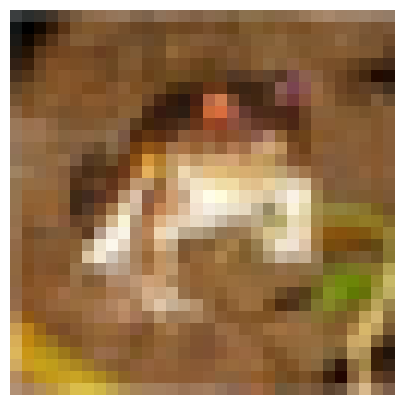

In [72]:
# Look at a sample to check it's working correctly
sel_idx = 0
img, label = analyze_dataset[sel_idx]

# Visualize the image
plot_img(img)

# Print its description
print(f'Description: {analyze_dataset.get_label_description(sel_idx)}')

# Print its shape
print(f'Image shape: {img.shape}\n')  # PIL image shape is (width, height)

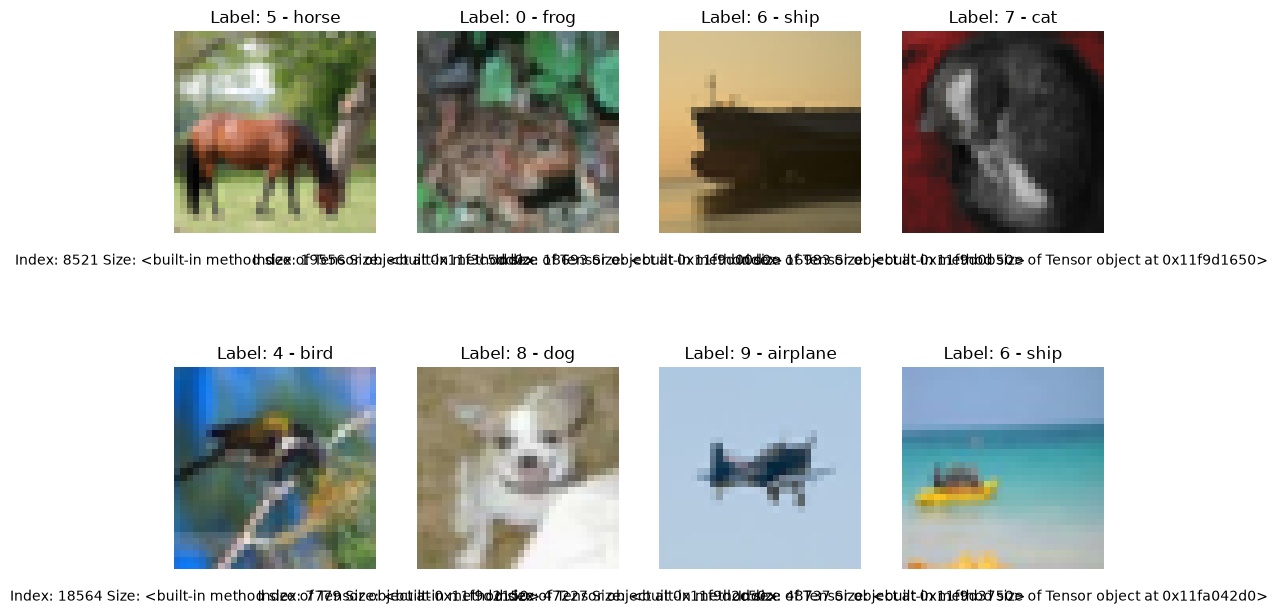

In [73]:
visual_exploration(analyze_dataset, num_rows=2, num_cols=4)

In [74]:
data_stats = {
    "mean": mean.tolist(),
    "std": std.tolist(),
}

Path("../configs").mkdir(exist_ok=True)

with open("../configs/data_stats.json", "w", encoding="utf-8") as file:
    json.dump(data_stats, file)

In [75]:
split = {
    "train_indices": analyze_split[0].indices,
    "val_indices": analyze_split[1].indices,
}

Path("../configs").mkdir(exist_ok=True)

with open("../configs/data_split.json", "w", encoding="utf-8") as file:
    json.dump(split, file)

In [76]:
output_path = Path("../data/processed/cifar10_metadata.parquet")
output_path.parent.mkdir(parents=True, exist_ok=True)

cifar_pd.to_csv("../data/processed/cifar10_metadata.csv", index=False)